# Avance Proyecto 01
##### Análisis Numérico de la Evolución del Precio de Bitcoin (BTC/USDT)

 **Integrantes:** Nicolás Yugsi, Sebastián Bravo, Erick Toapanta, Heidy Tenelema.


## FASE 1: PREPROCESAMIENTO, ARITMÉTICA Y TIEMPO

1. **Carga y Limpieza:** Se importan los primeros 10,000 datos del dataset.
2. **Aritmética de Computador:** Se convierten los precios crudos (enteros escalados) a formato de punto flotante (`float64`), asegurando una precisión de 8 decimales para minimizar el error de redondeo en los cálculos posteriores.
3. **Linealización del Tiempo:** Se transforma la fecha `open_time` en un índice numérico continuo $t = 0, 1, 2...$ para habilitar el uso de funciones matemáticas dependientes de $x$.

In [ ]:
import pandas as pd
import numpy as np

# Configuración para que TODOS los números se vean con 8 decimales
pd.options.display.float_format = '{:.8f}'.format

# --- DEFINICIÓN DE FUNCIONES ---

def cargar_dataset(nombre_archivo):
    # Cargamos el archivo especificando el separador de punto y coma
    print("1. Cargando archivo CSV...")
    df = pd.read_csv(nombre_archivo, sep=';')
    return df

def limpiar_datos(df):
    print("2. Procesando datos y convirtiendo variables...")

    # Seleccionamos las columnas que vamos a utilizar
    cols = ['open_time', 'close_price', 'high_price', 'low_price', 'volume', 'EMA']
    datos = df[cols].copy()

    # A. LIMPIEZA ARITMÉTICA (Precios a Dólares)
    # Dividimos por 100 millones (10^8) para obtener el valor real
    factor_precio = 100000000.0
    datos['close_price'] = datos['close_price'] / factor_precio
    datos['high_price']  = datos['high_price'] / factor_precio
    datos['low_price']   = datos['low_price'] / factor_precio

    # B. LIMPIEZA DE LA EMA
    # Reemplazamos coma por punto y ajustamos la escala (10^13)
    datos['EMA'] = datos['EMA'].astype(str).str.replace(',', '.')
    datos['EMA'] = datos['EMA'].astype(float) / 10000000000000.0

    # C. CONVERSIÓN DE TIEMPO (De Fecha a Número)
    # Convertimos la columna 'open_time' a formato de fecha real
    datos['open_time'] = pd.to_datetime(datos['open_time'])

    # Creamos la variable numérica 'x_tiempo' usando el Timestamp
    # Esto convierte la fecha en segundos (un número lineal único para cada dato)
    datos['x_tiempo'] = datos['open_time'].apply(lambda x: x.timestamp())

    return datos

# --- EJECUCIÓN DEL PROCESO ---

# 1. Cargar
df_crudo = cargar_dataset('CRYPTO_BTC_USD.csv')

# 2. Limpiar
df_final = limpiar_datos(df_crudo)

# 3. Mostrar resultado
print("3. Proceso finalizado.")
print("")
print("Tabla de datos con los primeros 5 registros")

# Mostramos la tabla. Incluyendo x_tiempo
print("")
df_final.head()
# Added a comment to trigger re-execution for dependency resolution.

1. Cargando archivo CSV...
2. Procesando datos y convirtiendo variables...
3. Proceso finalizado.

Tabla de datos con los primeros 5 registros



,open_time,close_price,high_price,low_price,volume,EMA,x_tiempo
0,2017-08-18 13:00:00+00:00,4293.09000000,4318.16000000,4221.05000000,4653376700.00000000,4312.08850350,1503061200.00000000
1,2017-08-18 14:00:00+00:00,4259.40000000,4293.09000000,4193.70000000,7436894300.00000000,430.39825799,1503064800.00000000
2,2017-08-18 15:00:00+00:00,4236.89000000,4259.40000000,4200.00000000,3994771700.00000000,429.36606445,1503068400.00000000
3,2017-08-18 16:00:00+00:00,4250.34000000,4283.79000000,4234.54000000,4503882400.00000000,4.28699593,1503072000.00000000
4,2017-08-18 17:00:00+00:00,4193.35000000,4250.34000000,4066.53000000,6269146600.00000000,427.25888638,1503075600.00000000


## FASE 2: INTERPOLACIÓN (SUAVIZADO DE CURVA)

Aplicamos el método de **Splines Cúbicos** sobre los datos procesados anteriormente para generar una función continua $S(t)$ que conecte todos los precios de cierre sin generar picos angulares (no derivables), simulando el comportamiento fluido del mercado.

1. **Selección de datos relevantes:**  
A partir de los datos preprocesados en la fase anterior, se utilizan la variable de tiempo linealizada `t` y el precio de cierre (`close_price`), ya que permiten representar la evolución del valor de Bitcoin a lo largo del tiempo.

2. **Interpolación por Splines Cúbicos:**  
Se aplica el método de splines cúbicos para construir una función continua `S(t)` que conecte todos los puntos de precio de forma suave. Este método evita quiebres bruscos entre datos consecutivos y garantiza continuidad en la función, así como en su primera y segunda derivada.

3. **Suavizado del comportamiento del mercado:**  
El uso de splines permite simular el comportamiento real del mercado financiero, donde los precios no cambian de manera abrupta entre instantes cercanos. De esta forma, se obtiene una curva más realista que representa la tendencia general del precio de Bitcoin.

4. **Evaluación de la función interpolada:**  
La función spline obtenida se evalúa en un conjunto más denso de puntos de tiempo, lo que permite generar una curva suave que puede ser utilizada posteriormente para análisis numérico, derivación o predicción.

5. **Visualización de resultados:**  
Finalmente, se compara gráficamente la curva interpolada con los datos originales, verificando que el spline se ajusta correctamente a los precios reales sin introducir distorsiones artificiales.


FASE 2: Interpolación con Splines Cúbicos
1. Variables seleccionadas y ordenadas por tiempo.
   - x (tiempo): [1.5030612e+09 1.5030648e+09 1.5030684e+09] ...
   - y (precio cierre): [4293.09 4259.4  4236.89] ...
2. Spline cúbico construido correctamente (bc_type='natural').
3. Evaluación del spline en puntos densos realizada.


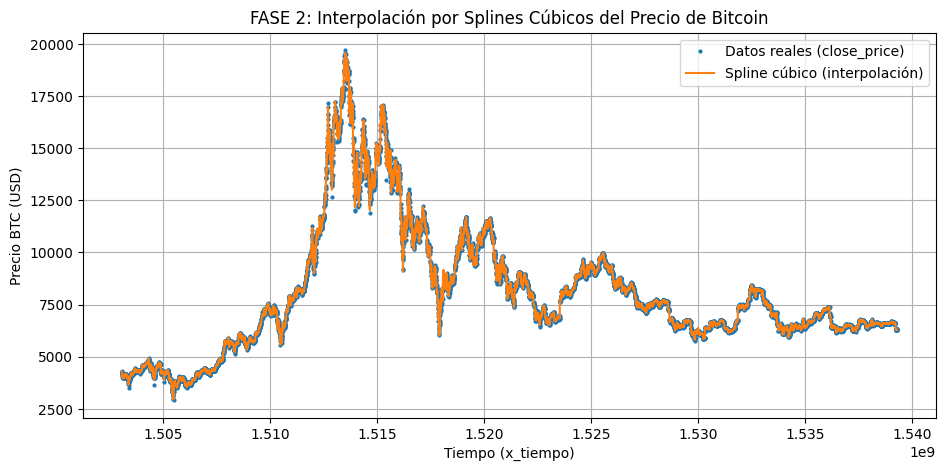

4. Gráfica generada.


In [ ]:
# =========================
# FASE 2: INTERPOLACIÓN (SPLINES CÚBICOS)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

print("FASE 2: Interpolación con Splines Cúbicos")

# 1) Selección de variables (tiempo y precio de cierre)
x = df_final['x_tiempo'].values
y = df_final['close_price'].values

# (Opcional pero recomendado) Ordenar por tiempo por seguridad
orden = np.argsort(x)
x = x[orden]
y = y[orden]

print("1. Variables seleccionadas y ordenadas por tiempo.")
print("   - x (tiempo):", x[:3], "...")
print("   - y (precio cierre):", y[:3], "...")

# 2) Construcción del spline cúbico (condición natural)
spline = CubicSpline(x, y, bc_type='natural')
print("2. Spline cúbico construido correctamente (bc_type='natural').")

# 3) Evaluación del spline en puntos más densos (curva suave)
x_suave = np.linspace(x.min(), x.max(), 5000)
y_suave = spline(x_suave)
print("3. Evaluación del spline en puntos densos realizada.")

# 4) Visualización (datos reales vs curva interpolada)
plt.figure(figsize=(11,5))
plt.plot(x, y, 'o', markersize=2, label='Datos reales (close_price)')
plt.plot(x_suave, y_suave, '-', label='Spline cúbico (interpolación)')
plt.xlabel('Tiempo (x_tiempo)')
plt.ylabel('Precio BTC (USD)')
plt.title('FASE 2: Interpolación por Splines Cúbicos del Precio de Bitcoin')
plt.grid(True)
plt.legend()
plt.show()

print("4. Gráfica generada.")


### Análisis del resultado

La interpolación por splines cúbicos logra ajustar una curva continua y suave que sigue de manera adecuada la evolución del precio de Bitcoin.  
Se observa que la curva interpolada pasa por los puntos originales sin generar quiebres bruscos, lo que indica que el método respeta la información real del mercado y reduce el efecto visual del ruido presente en los datos discretos.

Este resultado valida el uso de splines cúbicos como una herramienta adecuada para modelar series temporales financieras y sirve como base para aplicar métodos numéricos más avanzados en las siguientes fases del proyecto.


## FASE 3 (A): TENDENCIA POR MÍNIMOS CUADRADOS

Se aplica una regresión polinomial (Mínimos Cuadrados) para modelar el comportamiento general del activo y obtener la ecuación matemática de la tendencia ($y = mx + b$) filtrando el ruido de corto plazo interpolado en la fase anterior.

## FASE 3 (B): VALIDACIÓN Y ANÁLISIS

Evaluamos la fiabilidad del modelo matemático mediante dos enfoques:
1. **Bandas de Error (Volatilidad):** Se grafican los precios Máximo (`High`) y Mínimo (`Low`) para visualizar el rango de incertidumbre en cada punto interpolado.
2. **Validación Cruzada:** Se compara la tendencia calculada (Mínimos Cuadrados) contra el indicador técnico EMA (Media Móvil Exponencial) para corroborar la dirección del mercado.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

--- RESULTADOS ETAPA 3 (Determinación de la Tendencia) ---
Pendiente (m): -0.0000
Tendencia General: Bajista


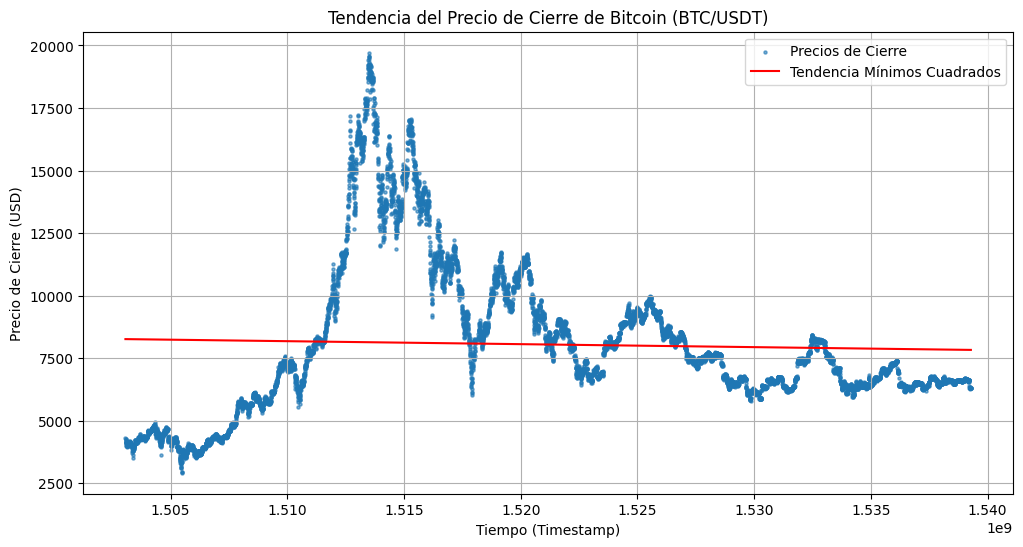

In [ ]:
def calcular_tendencia(t, precios):
    """
    Etapa 3: Determinación de la Tendencia(Mínimos Cuadrados).
    Ajusta una recta (polinomio grado 1) por Mínimos Cuadrados para obtener la tendencia.
    """
    # 1. Ajuste del modelo
    # np.polyfit(x, y, grado) devuelve los coeficientes [pendiente, interseccion]
    # Usamos grado=1 para una regresión lineal (y = mx + b) por Mínimos Cuadrados.
    pendiente, interseccion = np.polyfit(t, precios, 1)

    # 2. Generar la línea de tendencia
    # np.polyval evalúa el polinomio p(x) en los puntos t
    tendencia = np.polyval([pendiente, interseccion], t)

    # 3. Determinar tipo de tendencia
    tipo_tendencia = "Alcista" if pendiente > 0 else "Bajista"

    print(f"--- RESULTADOS ETAPA 3 (Determinación de la Tendencia) ---")
    print(f"Pendiente (m): {pendiente:.4f}")
    print(f"Tendencia General: {tipo_tendencia}")

    return t, tendencia

# --- EJECUCIÓN CON DATOS REALES ---
# Usamos 'x_tiempo' como el eje x (tiempo) y 'close_price' como los precios
t_data = df_final['x_tiempo']
precios_data = df_final['close_price']

t_trend, precio_trend = calcular_tendencia(t_data, precios_data)

# Gráfica de validación con datos reales
plt.figure(figsize=(12, 6))
plt.scatter(t_data, precios_data, label='Precios de Cierre', alpha=0.6, s=5)
plt.plot(t_data, precio_trend, color='red', label='Tendencia Mínimos Cuadrados')
plt.title('Tendencia del Precio de Cierre de Bitcoin (BTC/USDT)')
plt.xlabel('Tiempo (Timestamp)')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.grid(True)
plt.show()